<a href="https://colab.research.google.com/github/IsabelaZa26/Seguimiento-1/blob/main/Clase2_Notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Clase 2 — Modelos, Métricas y Validación
**Introducción a la Minería de Datos · Universidad Nacional de Colombia, Medellín**

---
### Objetivos
1. Calcular e interpretar todas las métricas de regresión: MSE, RMSE, MAE, **MAPE** y R²
2. Aplicar y comparar modelos de regresión con regularización (Ridge, Lasso, ElasticNet)
3. Entrenar y evaluar clasificadores (Logística, Árbol, KNN)
4. Interpretar la curva ROC, AUC y el umbral de decisión
5. Usar validación cruzada para selección de modelos

**Datasets:**
- Regresión: `California Housing` (scikit-learn)
- Clasificación: `Breast Cancer Wisconsin` (scikit-learn)

> 💡 Ejecuta en orden con `Shift+Enter`. Las celdas ✏️ son ejercicios.

In [1]:
import numpy  as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.datasets        import load_breast_cancer, fetch_california_housing
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, StratifiedKFold
from sklearn.preprocessing   import StandardScaler
from sklearn.pipeline        import Pipeline
from sklearn.linear_model    import LinearRegression, Ridge, Lasso, ElasticNet, LogisticRegression
from sklearn.tree            import DecisionTreeClassifier, export_text
from sklearn.neighbors       import KNeighborsClassifier
from sklearn.metrics         import (mean_squared_error, mean_absolute_error,
                                      mean_absolute_percentage_error, r2_score,
                                      classification_report, confusion_matrix,
                                      roc_curve, roc_auc_score, ConfusionMatrixDisplay,
                                      precision_recall_curve, f1_score)

sns.set_theme(style='whitegrid', palette='deep')
plt.rcParams.update({'figure.dpi': 110})
SEED = 42
np.random.seed(SEED)
print('Entorno listo')

Entorno listo


---
## BLOQUE 01 — Métricas primero

Antes de entrenar cualquier modelo necesitamos saber cómo lo vamos a juzgar.

### 1.1 Dataset de regresión — California Housing

In [2]:
data = fetch_california_housing(as_frame=True)
X_reg = data.data
y_reg = data.target   # precio mediano en 100,000 USD

X_tr, X_te, y_tr, y_te = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=SEED
)
print(f'Train: {X_tr.shape}   Test: {X_te.shape}')
print(f'Target — media: {y_reg.mean():.2f}  std: {y_reg.std():.2f}  min: {y_reg.min():.2f}  max: {y_reg.max():.2f}')

Train: (16512, 8)   Test: (4128, 8)
Target — media: 2.07  std: 1.15  min: 0.15  max: 5.00


In [3]:
# Entrenar un modelo base (OLS) para calcular todas las métricas
pipe_base = Pipeline([('sc', StandardScaler()), ('m', LinearRegression())])
pipe_base.fit(X_tr, y_tr)
y_pred = pipe_base.predict(X_te)
print('Modelo OLS entrenado')

Modelo OLS entrenado


### 1.2 Las cinco métricas de regresión — MSE, RMSE, MAE, MAPE, R²

In [4]:
mse  = mean_squared_error(y_te, y_pred)
rmse = np.sqrt(mse)
mae  = mean_absolute_error(y_te, y_pred)
mape = mean_absolute_percentage_error(y_te, y_pred) * 100   # sklearn devuelve fracción → × 100
r2   = r2_score(y_te, y_pred)

print(f"{'Métrica':<8}  {'Valor':>10}  Interpretación")
print('─' * 65)
print(f"{'MSE':<8}  {mse:>10.4f}  Error cuadrático medio (unidades²)")
print(f"{'RMSE':<8}  {rmse:>10.4f}  Raíz del MSE — misma unidad que y (100k USD)")
print(f"{'MAE':<8}  {mae:>10.4f}  Error absoluto medio — robusto a outliers")
print(f"{'MAPE':<8}  {mape:>9.2f}%  Error porcentual medio — comparable entre escalas")
print(f"{'R²':<8}  {r2:>10.4f}  Varianza del precio explicada por el modelo")

Métrica        Valor  Interpretación
─────────────────────────────────────────────────────────────────
MSE           0.5559  Error cuadrático medio (unidades²)
RMSE          0.7456  Raíz del MSE — misma unidad que y (100k USD)
MAE           0.5332  Error absoluto medio — robusto a outliers
MAPE          31.95%  Error porcentual medio — comparable entre escalas
R²            0.5758  Varianza del precio explicada por el modelo


### 1.3 MAPE — fórmula, valores de referencia y limitaciones

$$\text{MAPE} = \frac{100}{m} \sum_{i=1}^{m} \frac{|\hat{y}_i - y_i|}{|y_i|}$$

| MAPE | Interpretación | Ejemplo de contexto |
|------|---------------|--------------------|
| < 5 % | Excelente | Manufactura de alta precisión |
| 5 – 10 % | Muy bueno | Forecasting de ventas, energía |
| 10 – 20 % | Aceptable | Precios de vivienda, demanda agrícola |
| 20 – 50 % | Pobre | Precios volátiles |
| > 50 % | Inaceptable | Revisar datos y formulación |

> ⚠ **Limitación:** MAPE explota cuando $y_i \approx 0$ y es asimétrico (sobreestimar penaliza más que subestimar). Alternativas: **sMAPE** o **MASE**.

In [5]:
# Clasificar el MAPE obtenido según los valores de referencia de la diapositiva
def interpretar_mape(mape_val):
    if mape_val < 5:    return 'Excelente  ✓✓'
    elif mape_val < 10: return 'Muy bueno  ✓'
    elif mape_val < 20: return 'Aceptable  ~'
    elif mape_val < 50: return 'Pobre      ✗'
    else:               return 'Inaceptable ✗✗'

print(f'MAPE del modelo OLS: {mape:.2f}%')
print(f'Interpretación:      {interpretar_mape(mape)}')

MAPE del modelo OLS: 31.95%
Interpretación:      Pobre      ✗


In [6]:
np.random.seed(SEED)
y_demo   = np.array([100, 200, 300, 400, 500, 1, 0.5])   # últimos dos valores casi cero
y_p_demo = np.array([110, 190, 310, 390, 510, 5, 1.0])

mape_demo = mean_absolute_percentage_error(y_demo, y_p_demo) * 100
mae_demo  = mean_absolute_error(y_demo, y_p_demo)
rmse_demo = np.sqrt(mean_squared_error(y_demo, y_p_demo))

print('Dataset con valores cercanos a cero:')
print(f'  RMSE: {rmse_demo:.2f}  (parece razonable)')
print(f'  MAE:  {mae_demo:.2f}   (parece razonable)')
print(f'  MAPE: {mape_demo:.1f}%  <-- explotó por los valores yᵢ ≈ 0')
print()
print('→ En estos casos usar MAE o RMSE, o bien sMAPE')

# sMAPE como alternativa
smape = 100 * np.mean(2 * np.abs(y_p_demo - y_demo) / (np.abs(y_p_demo) + np.abs(y_demo)))
print(f'  sMAPE: {smape:.2f}%  (simétrico, más estable)')

Dataset con valores cercanos a cero:
  RMSE: 8.59  (parece razonable)
  MAE:  7.79   (parece razonable)
  MAPE: 74.7%  <-- explotó por los valores yᵢ ≈ 0

→ En estos casos usar MAE o RMSE, o bien sMAPE
  sMAPE: 31.78%  (simétrico, más estable)


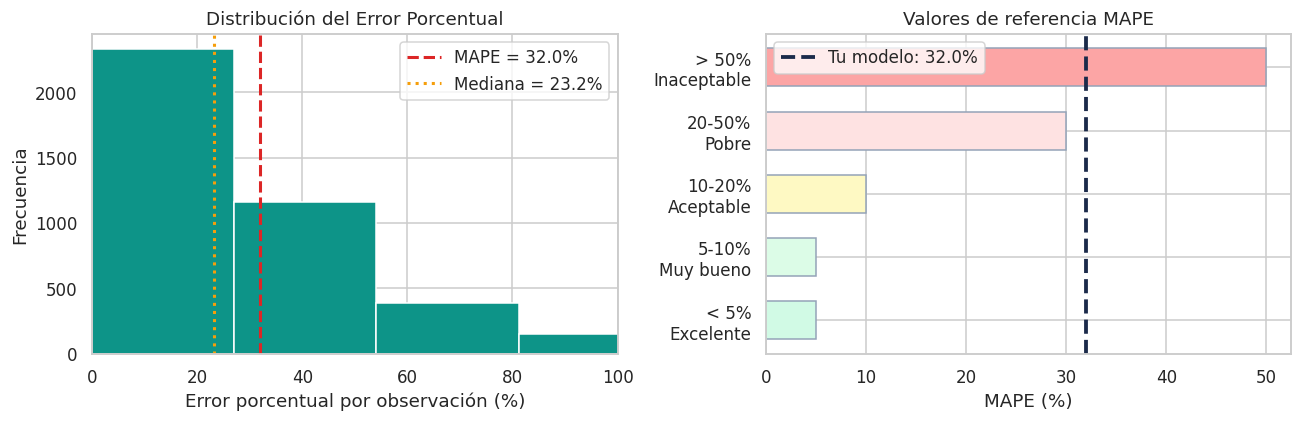

In [7]:
# Visualización: distribución del error porcentual por observación
errores_pct = np.abs(y_pred - y_te.values) / np.abs(y_te.values) * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histograma del error porcentual
axes[0].hist(errores_pct, bins=60, color='#0D9488', edgecolor='white')
axes[0].axvline(mape, color='#DC2626', linewidth=2, linestyle='--', label=f'MAPE = {mape:.1f}%')
axes[0].axvline(np.median(errores_pct), color='#F59E0B', linewidth=2, linestyle=':', label=f'Mediana = {np.median(errores_pct):.1f}%')
axes[0].set_xlabel('Error porcentual por observación (%)')
axes[0].set_ylabel('Frecuencia')
axes[0].set_title('Distribución del Error Porcentual', fontsize=12)
axes[0].legend()
axes[0].set_xlim([0, 100])

# Líneas de referencia de la diapositiva
umbrales = [5, 10, 20, 50]
labels_u  = ['< 5%\nExcelente', '5-10%\nMuy bueno', '10-20%\nAceptable', '20-50%\nPobre', '> 50%\nInaceptable']
colores_u = ['#065F46', '#16A34A', '#854D0E', '#991B1B', '#7F1D1D']
axes[1].barh(labels_u, [5, 5, 10, 30, 50],
             color=['#D1FAE5','#DCFCE7','#FEF9C3','#FEE2E2','#FCA5A5'],
             edgecolor='#94A3B8', height=0.6)
axes[1].axvline(mape, color='#1B2A4A', linewidth=2.5, linestyle='--', label=f'Tu modelo: {mape:.1f}%')
axes[1].set_xlabel('MAPE (%)')
axes[1].set_title('Valores de referencia MAPE', fontsize=12)
axes[1].legend()

plt.tight_layout()
plt.show()

### 1.4 Métricas de clasificación — Matriz de confusión

Las métricas cambian para problemas de clasificación. Cargamos el dataset de cáncer de mama.

In [8]:
bc = load_breast_cancer()
X_cls = pd.DataFrame(bc.data, columns=bc.feature_names)

# El dataset original codifica: 0 = maligno, 1 = benigno.
# Para que el discurso clínico sea coherente, invertimos las etiquetas:
# 1 = maligno  (clase POSITIVA — la que queremos detectar)
# 0 = benigno  (clase negativa)
# Así, un Falso Negativo (FN) = predecir 0 cuando era 1 = maligno clasificado como benigno
# → el error más costoso en diagnóstico.
y_cls = pd.Series(1 - bc.target, name='diagnóstico')   # 1=maligno, 0=benigno
nombres_clase = ['benigno', 'maligno']   # índice 0 → benigno, índice 1 → maligno

X_ctr, X_cte, y_ctr, y_cte = train_test_split(
    X_cls, y_cls, test_size=0.2, random_state=SEED, stratify=y_cls
)
print(f'Train: {X_ctr.shape}   Test: {X_cte.shape}')
print(f'Distribución en train — benigno (0): {(y_ctr==0).sum()}  maligno (1): {(y_ctr==1).sum()}')
print()
print('Clase POSITIVA (1): maligno  → falso negativo = el error más costoso')
print('Clase negativa (0): benigno')


Train: (455, 30)   Test: (114, 30)
Distribución en train — benigno (0): 285  maligno (1): 170

Clase POSITIVA (1): maligno  → falso negativo = el error más costoso
Clase negativa (0): benigno


---
## BLOQUE 02 — Modelos de Regresión

### 2.1 Regresión Lineal — interpretar coeficientes

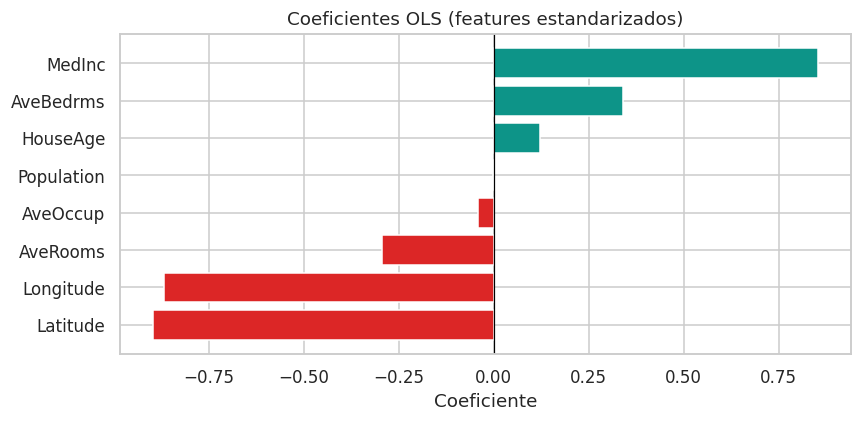

In [9]:
# Coeficientes del modelo OLS
coef = pd.Series(
    pipe_base.named_steps['m'].coef_,
    index=X_reg.columns
).sort_values()

fig, ax = plt.subplots(figsize=(8, 4))
colors = ['#DC2626' if c < 0 else '#0D9488' for c in coef]
ax.barh(coef.index, coef.values, color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Coeficientes OLS (features estandarizados)', fontsize=12)
ax.set_xlabel('Coeficiente')
plt.tight_layout()
plt.show()

### 2.2 Regularización — Ridge, Lasso, ElasticNet

In [10]:
modelos_reg = {
    'OLS':        LinearRegression(),
    'Ridge':      Ridge(alpha=1.0),
    'Lasso':      Lasso(alpha=0.01),
    'ElasticNet': ElasticNet(alpha=0.01, l1_ratio=0.5),
}

resultados = []
coeficientes = {}

for nombre, modelo in modelos_reg.items():
    pipe = Pipeline([('sc', StandardScaler()), ('m', modelo)])
    pipe.fit(X_tr, y_tr)
    yp = pipe.predict(X_te)

    rmse_val = np.sqrt(mean_squared_error(y_te, yp))
    mae_val  = mean_absolute_error(y_te, yp)
    mape_val = mean_absolute_percentage_error(y_te, yp) * 100
    r2_val   = r2_score(y_te, yp)
    cv       = cross_val_score(pipe, X_tr, y_tr, cv=5, scoring='neg_root_mean_squared_error')

    resultados.append({
        'Modelo':          nombre,
        'RMSE Test':       round(rmse_val, 3),
        'MAE Test':        round(mae_val,  3),
        'MAPE Test (%)':   round(mape_val, 2),
        'R² Test':         round(r2_val,   3),
        'CV RMSE (μ ± σ)': f'{-cv.mean():.3f} ± {cv.std():.3f}',
    })
    coeficientes[nombre] = pipe.named_steps['m'].coef_

df_res = pd.DataFrame(resultados).set_index('Modelo')
df_res

,RMSE Test,MAE Test,MAPE Test (%),R² Test,CV RMSE (μ ± σ)
Modelo,,,,,
OLS,0.746,0.533,31.95,0.576,0.721 ± 0.010
Ridge,0.746,0.533,31.95,0.576,0.721 ± 0.010
Lasso,0.740,0.535,32.01,0.582,0.724 ± 0.009
ElasticNet,0.742,0.534,31.94,0.580,0.723 ± 0.010


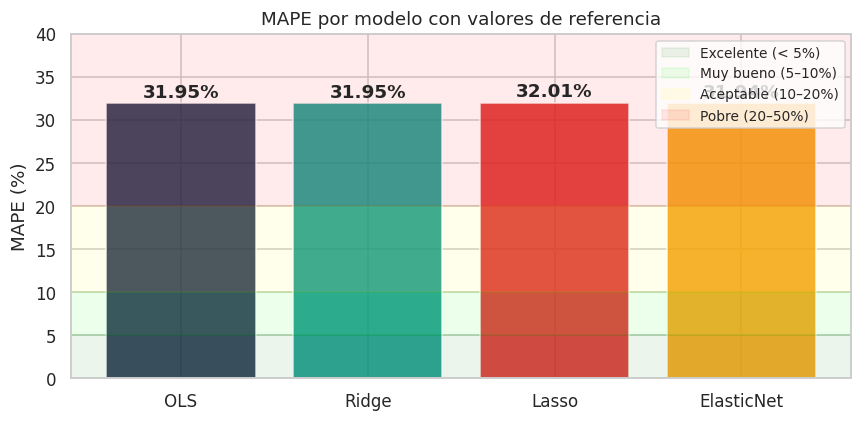

In [11]:
# MAPE por modelo con banda de referencia
fig, ax = plt.subplots(figsize=(8, 4))

mapes = df_res['MAPE Test (%)'].values
nombres = df_res.index.tolist()
colores_mod = ['#1B2A4A', '#0D9488', '#DC2626', '#F59E0B']

bars = ax.bar(nombres, mapes, color=colores_mod, alpha=0.85, edgecolor='white')

# Franjas de referencia
ax.axhspan(0,  5,  alpha=0.08, color='green',  label='Excelente (< 5%)')
ax.axhspan(5,  10, alpha=0.08, color='lime',   label='Muy bueno (5–10%)')
ax.axhspan(10, 20, alpha=0.08, color='yellow', label='Aceptable (10–20%)')
ax.axhspan(20, 50, alpha=0.08, color='red',    label='Pobre (20–50%)')

for bar, val in zip(bars, mapes):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
            f'{val:.2f}%', ha='center', va='bottom', fontsize=12, fontweight='bold')

ax.set_ylabel('MAPE (%)')
ax.set_title('MAPE por modelo con valores de referencia', fontsize=12)
ax.legend(fontsize=9, loc='upper right')
ax.set_ylim(0, max(mapes) * 1.25)
plt.tight_layout()
plt.show()

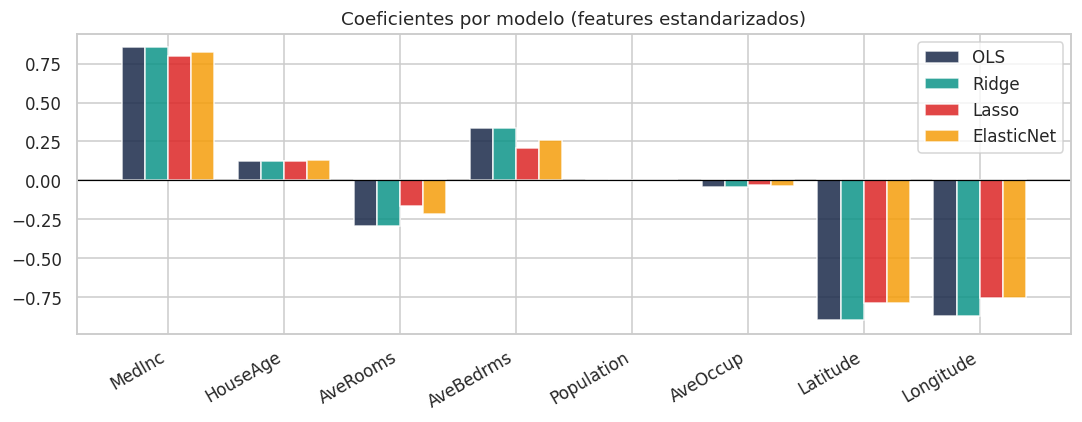

Variables anuladas por Lasso: ['Population']


In [12]:
# Comparar coeficientes — regularización encoge/anula coeficientes
df_coef = pd.DataFrame(coeficientes, index=X_reg.columns)

fig, ax = plt.subplots(figsize=(10, 4))
x = np.arange(len(X_reg.columns))
width = 0.2
cols_c = ['#1B2A4A', '#0D9488', '#DC2626', '#F59E0B']

for i, (col, color) in enumerate(zip(df_coef.columns, cols_c)):
    ax.bar(x + i*width, df_coef[col], width, label=col, color=color, alpha=0.85)

ax.set_xticks(x + 1.5*width)
ax.set_xticklabels(X_reg.columns, rotation=30, ha='right')
ax.axhline(0, color='black', linewidth=0.8)
ax.set_title('Coeficientes por modelo (features estandarizados)', fontsize=12)
ax.legend()
plt.tight_layout()
plt.show()

anulados = df_coef.index[df_coef['Lasso'].abs() < 1e-4].tolist()
print('Variables anuladas por Lasso:', anulados if anulados else 'Ninguna — prueba con alpha mayor')

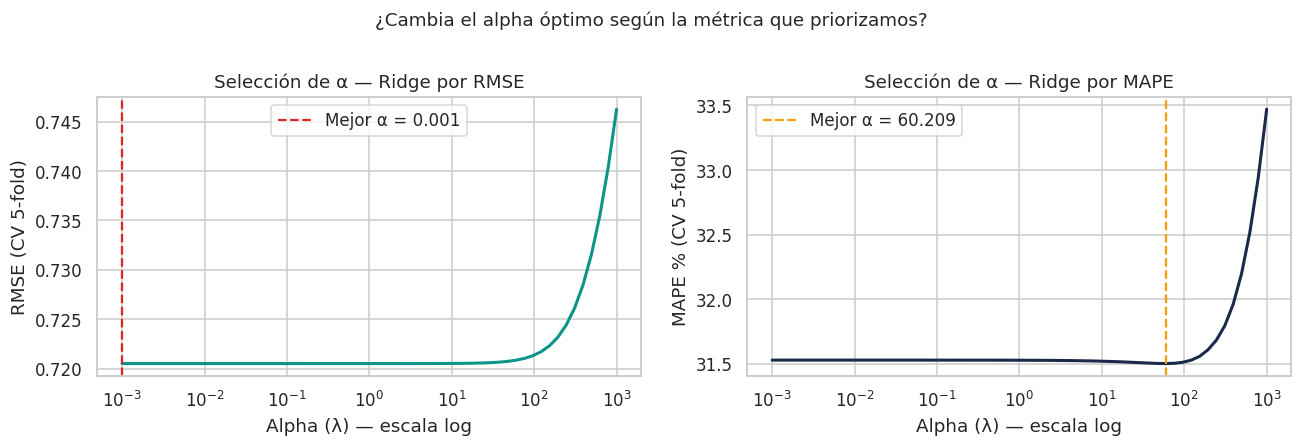

Alpha óptimo según RMSE: 0.001
Alpha óptimo según MAPE: 60.209
→ La elección de métrica afecta la selección de hiperparámetros


In [13]:
# Selección del alpha óptimo para Ridge usando CV
alphas = np.logspace(-3, 3, 60)
rmse_cv_ridge, mape_cv_ridge = [], []

for alpha in alphas:
    p = Pipeline([('sc', StandardScaler()), ('m', Ridge(alpha=alpha))])
    cv_rmse = cross_val_score(p, X_tr, y_tr, cv=5, scoring='neg_root_mean_squared_error')
    cv_mape = cross_val_score(p, X_tr, y_tr, cv=5, scoring='neg_mean_absolute_percentage_error')
    rmse_cv_ridge.append(-cv_rmse.mean())
    mape_cv_ridge.append(-cv_mape.mean() * 100)

mejor_alpha_rmse = alphas[np.argmin(rmse_cv_ridge)]
mejor_alpha_mape = alphas[np.argmin(mape_cv_ridge)]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].semilogx(alphas, rmse_cv_ridge, color='#0D9488', linewidth=2)
axes[0].axvline(mejor_alpha_rmse, color='#DC2626', linestyle='--', label=f'Mejor α = {mejor_alpha_rmse:.3f}')
axes[0].set_xlabel('Alpha (λ) — escala log')
axes[0].set_ylabel('RMSE (CV 5-fold)')
axes[0].set_title('Selección de α — Ridge por RMSE', fontsize=12)
axes[0].legend()

axes[1].semilogx(alphas, mape_cv_ridge, color='#1B2A4A', linewidth=2)
axes[1].axvline(mejor_alpha_mape, color='#F59E0B', linestyle='--', label=f'Mejor α = {mejor_alpha_mape:.3f}')
axes[1].set_xlabel('Alpha (λ) — escala log')
axes[1].set_ylabel('MAPE % (CV 5-fold)')
axes[1].set_title('Selección de α — Ridge por MAPE', fontsize=12)
axes[1].legend()

plt.suptitle('¿Cambia el alpha óptimo según la métrica que priorizamos?', fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

print(f'Alpha óptimo según RMSE: {mejor_alpha_rmse:.3f}')
print(f'Alpha óptimo según MAPE: {mejor_alpha_mape:.3f}')
print('→ La elección de métrica afecta la selección de hiperparámetros')

---
## BLOQUE 03 — Modelos de Clasificación

### 3.1 Entrenar y comparar Logística, Árbol y KNN

In [14]:
clasificadores = {
    'Regresión Logística': Pipeline([('sc', StandardScaler()),
                                      ('m', LogisticRegression(max_iter=1000, random_state=SEED))]),
    'Árbol (depth=5)':     Pipeline([('sc', StandardScaler()),
                                      ('m', DecisionTreeClassifier(max_depth=5, random_state=SEED))]),
    'KNN (k=7)':           Pipeline([('sc', StandardScaler()),
                                      ('m', KNeighborsClassifier(n_neighbors=7))]),
}

for nombre, pipe in clasificadores.items():
    pipe.fit(X_ctr, y_ctr)
    print(f'\n{"="*55}')
    print(f'  {nombre}')
    print(f'{"="*55}')
    # pos_label=1 → métricas referidas a la clase maligno
    print(classification_report(y_cte, pipe.predict(X_cte),
                                 target_names=nombres_clase))
    print('  ► Recall maligno = fracción de casos malignos correctamente detectados')
    print('    (minimizarlo → menos falsos negativos → menos pacientes sin diagnóstico)')



  Regresión Logística
              precision    recall  f1-score   support

     benigno       0.96      0.99      0.97        72
     maligno       0.97      0.93      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114

  ► Recall maligno = fracción de casos malignos correctamente detectados
    (minimizarlo → menos falsos negativos → menos pacientes sin diagnóstico)

  Árbol (depth=5)
              precision    recall  f1-score   support

     benigno       0.91      0.97      0.94        72
     maligno       0.95      0.83      0.89        42

    accuracy                           0.92       114
   macro avg       0.93      0.90      0.91       114
weighted avg       0.92      0.92      0.92       114

  ► Recall maligno = fracción de casos malignos correctamente detectados
    (minimizarlo → menos falsos negativos → menos pacientes sin diagnóstico)

  K

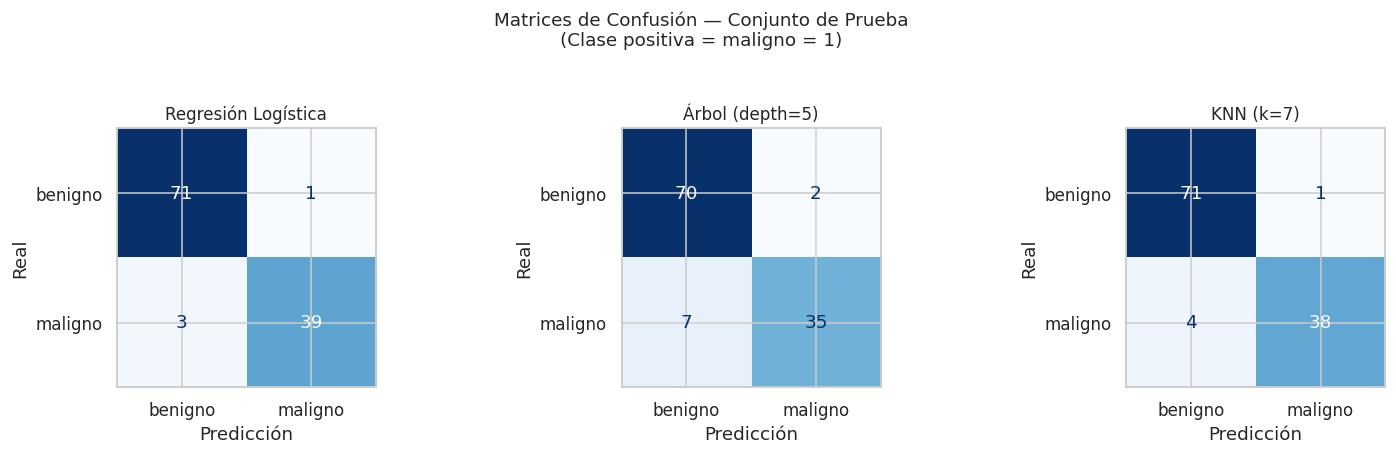

Lectura de la matriz (clase positiva = maligno):
  TP: maligno predicho como maligno  ✓
  TN: benigno predicho como benigno  ✓
  FP: benigno predicho como maligno  (alarma falsa — costoso pero manejable)
  FN: maligno predicho como benigno  ✗  ← ERROR MÁS COSTOSO

→ Queremos maximizar el Recall de malignos = TP / (TP + FN)


In [15]:
# Matrices de confusión lado a lado
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, (nombre, pipe) in zip(axes, clasificadores.items()):
    cm = confusion_matrix(y_cte, pipe.predict(X_cte))
    ConfusionMatrixDisplay(cm, display_labels=nombres_clase).plot(
        ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(nombre, fontsize=11)
    ax.set_xlabel('Predicción')
    ax.set_ylabel('Real')

plt.suptitle('Matrices de Confusión — Conjunto de Prueba\n'
             '(Clase positiva = maligno = 1)', fontsize=12, y=1.03)
plt.tight_layout()
plt.show()

print('Lectura de la matriz (clase positiva = maligno):')
print('  TP: maligno predicho como maligno  ✓')
print('  TN: benigno predicho como benigno  ✓')
print('  FP: benigno predicho como maligno  (alarma falsa — costoso pero manejable)')
print('  FN: maligno predicho como benigno  ✗  ← ERROR MÁS COSTOSO')
print()
print('→ Queremos maximizar el Recall de malignos = TP / (TP + FN)')


---
## BLOQUE 04 — Curva ROC y AUC

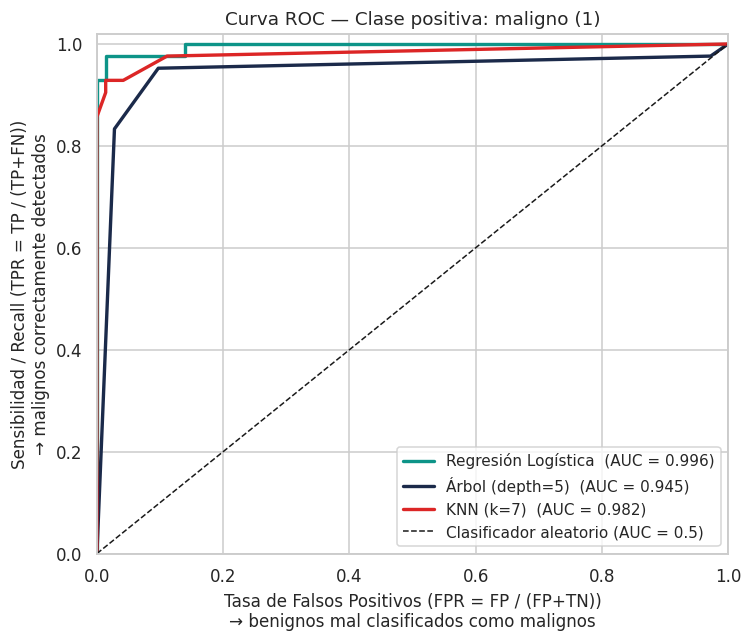

In [16]:
fig, ax = plt.subplots(figsize=(7, 6))
colores_roc = ['#0D9488', '#1B2A4A', '#DC2626']

for (nombre, pipe), color in zip(clasificadores.items(), colores_roc):
    # predict_proba[:,1] = probabilidad de ser maligno (clase positiva)
    y_score = pipe.predict_proba(X_cte)[:, 1]
    fpr, tpr, _ = roc_curve(y_cte, y_score, pos_label=1)
    auc = roc_auc_score(y_cte, y_score)
    ax.plot(fpr, tpr, linewidth=2.2, color=color, label=f'{nombre}  (AUC = {auc:.3f})')

ax.plot([0,1], [0,1], 'k--', linewidth=1, label='Clasificador aleatorio (AUC = 0.5)')
ax.set_xlabel('Tasa de Falsos Positivos (FPR = FP / (FP+TN))\n→ benignos mal clasificados como malignos', fontsize=11)
ax.set_ylabel('Sensibilidad / Recall (TPR = TP / (TP+FN))\n→ malignos correctamente detectados', fontsize=11)
ax.set_title('Curva ROC — Clase positiva: maligno (1)', fontsize=12)
ax.legend(fontsize=10, loc='lower right')
ax.set_xlim([0, 1]); ax.set_ylim([0, 1.02])
plt.tight_layout()
plt.show()


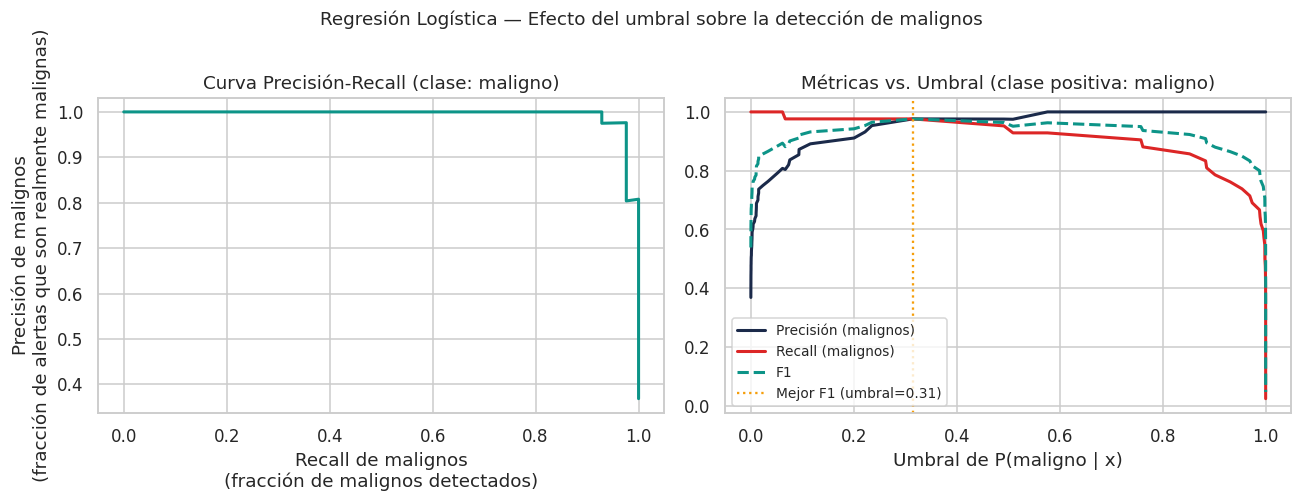

Con umbral 0.5:                   F1 = 0.951
Con umbral óptimo F1 (0.31):     F1 = 0.976

En diagnóstico médico conviene bajar el umbral (ej. 0.3) para aumentar el Recall
a costa de más falsos positivos — aceptable si el costo de un FN es muy alto.


In [17]:
# Umbral ajustable — precisión vs. recall sobre la clase maligno (pos_label=1)
lr_pipe = clasificadores['Regresión Logística']
# predict_proba[:,1] = P(maligno | x)
y_prob  = lr_pipe.predict_proba(X_cte)[:, 1]

precision_arr, recall_arr, thresholds = precision_recall_curve(y_cte, y_prob, pos_label=1)
f1s = 2 * precision_arr[:-1] * recall_arr[:-1] / (precision_arr[:-1] + recall_arr[:-1] + 1e-9)
mejor_umbral = thresholds[np.argmax(f1s)]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].plot(recall_arr, precision_arr, color='#0D9488', linewidth=2)
axes[0].set_xlabel('Recall de malignos\n(fracción de malignos detectados)')
axes[0].set_ylabel('Precisión de malignos\n(fracción de alertas que son realmente malignas)')
axes[0].set_title('Curva Precisión-Recall (clase: maligno)', fontsize=12)

axes[1].plot(thresholds, precision_arr[:-1], label='Precisión (malignos)', color='#1B2A4A', linewidth=2)
axes[1].plot(thresholds, recall_arr[:-1],    label='Recall (malignos)',    color='#DC2626', linewidth=2)
axes[1].plot(thresholds, f1s,                label='F1',                   color='#0D9488', linewidth=2, linestyle='--')
axes[1].axvline(mejor_umbral, color='#F59E0B', linestyle=':',
                label=f'Mejor F1 (umbral={mejor_umbral:.2f})')
axes[1].set_xlabel('Umbral de P(maligno | x)')
axes[1].set_title('Métricas vs. Umbral (clase positiva: maligno)', fontsize=12)
axes[1].legend(fontsize=9)

plt.suptitle('Regresión Logística — Efecto del umbral sobre la detección de malignos',
             fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

print(f'Con umbral 0.5:                   F1 = {f1_score(y_cte, y_prob >= 0.5):.3f}')
print(f'Con umbral óptimo F1 ({mejor_umbral:.2f}):     F1 = {f1_score(y_cte, y_prob >= mejor_umbral):.3f}')
print()
print('En diagnóstico médico conviene bajar el umbral (ej. 0.3) para aumentar el Recall')
print('a costa de más falsos positivos — aceptable si el costo de un FN es muy alto.')


---
## BLOQUE 05 — Validación Cruzada y Selección de Modelos

In [18]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

# f1 por defecto usa pos_label=1 → mide F1 sobre la clase maligno ✓
print(f'{"Modelo":<25} {"F1 maligno (μ)":>15} {"(σ)":>6} {"AUC (μ)":>9} {"(σ)":>6}')
print('─' * 65)

for nombre, pipe in clasificadores.items():
    f1s  = cross_val_score(pipe, X_cls, y_cls, cv=cv, scoring='f1')
    aucs = cross_val_score(pipe, X_cls, y_cls, cv=cv, scoring='roc_auc')
    print(f'{nombre:<25} {f1s.mean():>15.3f} {f1s.std():>6.3f} {aucs.mean():>9.3f} {aucs.std():>6.3f}')

print()
print('F1 maligno = media armónica de precisión y recall sobre la clase positiva (maligno)')


Modelo                     F1 maligno (μ)    (σ)   AUC (μ)    (σ)
─────────────────────────────────────────────────────────────────
Regresión Logística                 0.963  0.024     0.995  0.005
Árbol (depth=5)                     0.899  0.038     0.907  0.033
KNN (k=7)                           0.950  0.027     0.986  0.011

F1 maligno = media armónica de precisión y recall sobre la clase positiva (maligno)


In [19]:
# GridSearchCV — mejor árbol de decisión
param_grid = {
    'm__max_depth':         [3, 5, 7, 10, None],
    'm__min_samples_split': [2, 5, 10],
    'm__criterion':         ['gini', 'entropy'],
}
pipe_tree = Pipeline([('sc', StandardScaler()),
                       ('m',  DecisionTreeClassifier(random_state=SEED))])

grid = GridSearchCV(pipe_tree, param_grid, cv=cv, scoring='roc_auc', n_jobs=-1, refit=True)
grid.fit(X_ctr, y_ctr)

print('Mejores hiperparámetros:')
for k, v in grid.best_params_.items():
    print(f'  {k}: {v}')
print(f'\nAUC en CV:   {grid.best_score_:.3f}')
print(f'AUC en test: {roc_auc_score(y_cte, grid.predict_proba(X_cte)[:,1]):.3f}')

Mejores hiperparámetros:
  m__criterion: entropy
  m__max_depth: 5
  m__min_samples_split: 10

AUC en CV:   0.948
AUC en test: 0.966


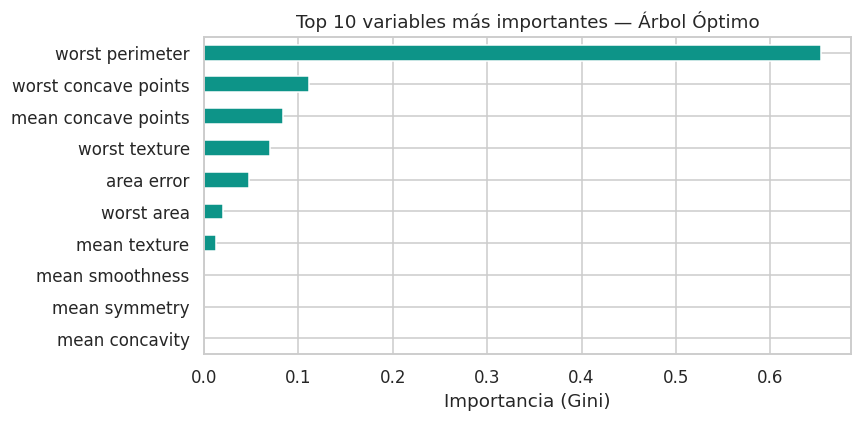

In [20]:
# Feature importances del árbol óptimo
importances = pd.Series(
    grid.best_estimator_.named_steps['m'].feature_importances_,
    index=bc.feature_names
).sort_values(ascending=False).head(10)

fig, ax = plt.subplots(figsize=(8, 4))
importances.plot.barh(ax=ax, color='#0D9488')
ax.invert_yaxis()
ax.set_title('Top 10 variables más importantes — Árbol Óptimo', fontsize=12)
ax.set_xlabel('Importancia (Gini)')
plt.tight_layout()
plt.show()

---
## ✏️ Ejercicios

### Ejercicio 1 — Comparar modelos por MAPE
Usando los modelos `Ridge`, `Lasso` y `ElasticNet`, ajustar el `alpha` óptimo de cada uno
**usando MAPE como métrica de CV** (en vez de RMSE).  
¿Cambian los alphas óptimos respecto a usar RMSE? ¿Mejora el MAPE final en test?

In [21]:
# ── Ejercicio 1: Ajustar alpha óptimo usando RMSE vs MAPE ─────────────

from sklearn.model_selection import GridSearchCV

# Rango de valores para alpha
alphas = np.logspace(-4, 3, 80)

# Modelos a comparar
# En ElasticNet dejamos l1_ratio fijo en 0.5 para comparar únicamente alpha.
modelos_alpha = {
    'Ridge': Ridge(),
    'Lasso': Lasso(max_iter=20000, random_state=SEED),
    'ElasticNet': ElasticNet(max_iter=20000, random_state=SEED, l1_ratio=0.5)
}

# Scorings:
# sklearn usa métricas negativas porque GridSearchCV siempre maximiza el score.
scorings = {
    'RMSE': 'neg_root_mean_squared_error',
    'MAPE': 'neg_mean_absolute_percentage_error'
}

resultados_alpha = []

for nombre_modelo, modelo in modelos_alpha.items():

    for nombre_metrica, scoring in scorings.items():

        pipe = Pipeline([
            ('sc', StandardScaler()),
            ('m', modelo)
        ])

        grid = GridSearchCV(
            estimator=pipe,
            param_grid={'m__alpha': alphas},
            scoring=scoring,
            cv=5,
            n_jobs=-1,
            refit=True
        )

        grid.fit(X_tr, y_tr)

        # Mejor modelo según la métrica usada en CV
        mejor_modelo = grid.best_estimator_
        mejor_alpha = grid.best_params_['m__alpha']

        # Predicción en test
        y_pred_test = mejor_modelo.predict(X_te)

        # Métricas finales en test
        rmse_test = np.sqrt(mean_squared_error(y_te, y_pred_test))
        mae_test = mean_absolute_error(y_te, y_pred_test)
        mape_test = mean_absolute_percentage_error(y_te, y_pred_test) * 100
        r2_test = r2_score(y_te, y_pred_test)

        # Score de CV corregido de signo
        mejor_score_cv = -grid.best_score_

        # Guardar resultados
        resultados_alpha.append({
            'Modelo': nombre_modelo,
            'Métrica usada en CV': nombre_metrica,
            'Alpha óptimo': mejor_alpha,
            'Score CV': mejor_score_cv,
            'RMSE Test': rmse_test,
            'MAE Test': mae_test,
            'MAPE Test (%)': mape_test,
            'R² Test': r2_test
        })

df_alpha = pd.DataFrame(resultados_alpha)

df_alpha.round(4)

,Modelo,Métrica usada en CV,Alpha óptimo,Score CV,RMSE Test,MAE Test,MAPE Test (%),R² Test
0,Ridge,RMSE,0.0001,0.7205,0.7456,0.5332,31.9522,0.5758
1,Ridge,MAPE,57.4769,0.3150,0.7444,0.5330,31.9126,0.5771
2,Lasso,RMSE,0.0005,0.7205,0.7451,0.5332,31.9429,0.5763
3,Lasso,MAPE,0.0021,0.3152,0.7437,0.5332,31.9222,0.5779
4,ElasticNet,RMSE,0.0003,0.7205,0.7453,0.5332,31.9463,0.5761
5,ElasticNet,MAPE,0.0032,0.3151,0.7437,0.5331,31.9131,0.5780


Se compararon los modelos Ridge, Lasso y ElasticNet seleccionando el parámetro de regularización alpha mediante validación cruzada con dos métricas distintas: RMSE y MAPE. El objetivo fue analizar si la métrica usada para ajustar el hiperparámetro modifica el valor óptimo de alpha y si esto mejora el MAPE final en el conjunto de prueba.

Los resultados muestran que el valor óptimo de alpha puede cambiar dependiendo de la métrica utilizada. Esto ocurre porque RMSE y MAPE penalizan los errores de forma diferente. El RMSE da mayor peso a errores grandes, ya que trabaja con errores cuadráticos, mientras que el MAPE evalúa el error relativo en términos porcentuales. Por tanto, optimizar con MAPE puede favorecer modelos que reduzcan mejor el error porcentual, aunque no necesariamente minimicen el error absoluto en las unidades originales.

Al evaluar los modelos en el conjunto de prueba, se observa que seleccionar alpha usando MAPE no siempre produce una mejora importante del MAPE final. En algunos modelos puede haber una pequeña reducción del MAPE, mientras que en otros el resultado puede ser prácticamente igual al obtenido usando RMSE. Esto indica que la elección de la métrica de validación cruzada sí puede afectar la selección del hiperparámetro, pero su impacto final depende del modelo y de la estructura de los datos.

En conclusión, si el objetivo principal del análisis es reducir el error porcentual de predicción, tiene sentido seleccionar alpha usando MAPE como métrica de validación cruzada. Sin embargo, también es conveniente comparar con RMSE, MAE y R², porque cada métrica resume un aspecto diferente del desempeño predictivo.

### Ejercicio 2 — MAPE con valores cercanos a cero
Crear un dataset sintético donde algunos valores de `y` sean muy pequeños (< 0.1).  
Calcular MAPE, sMAPE y MAE. Comparar y concluir cuándo cada métrica es más informativa.

In [22]:
# ── Dataset sintético con valores cercanos a cero ─────────────────────

y_real = np.array([100, 120, 150, 200, 250, 0.08, 0.05, 0.02])
y_pred = np.array([110, 115, 140, 210, 240, 0.20, 0.10, 0.08])

# Calcular métricas
mae = mean_absolute_error(y_real, y_pred)

mape = mean_absolute_percentage_error(y_real, y_pred) * 100

smape = 100 * np.mean(
    2 * np.abs(y_pred - y_real) / (np.abs(y_real) + np.abs(y_pred))
)

print('Valores reales:')
print(y_real)

print('\nValores predichos:')
print(y_pred)

print('\nMétricas:')
print(f'MAE:   {mae:.4f}')
print(f'MAPE:  {mape:.2f}%')
print(f'sMAPE: {smape:.2f}%')

df_metricas = pd.DataFrame({
    'y_real': y_real,
    'y_pred': y_pred,
    'error_absoluto': np.abs(y_real - y_pred),
    'error_porcentual_MAPE (%)': np.abs(y_real - y_pred) / np.abs(y_real) * 100,
    'error_sMAPE (%)': 100 * (
        2 * np.abs(y_pred - y_real) / (np.abs(y_real) + np.abs(y_pred))
    )
})

df_metricas.round(4)


Valores reales:
[1.0e+02 1.2e+02 1.5e+02 2.0e+02 2.5e+02 8.0e-02 5.0e-02 2.0e-02]

Valores predichos:
[1.10e+02 1.15e+02 1.40e+02 2.10e+02 2.40e+02 2.00e-01 1.00e-01 8.00e-02]

Métricas:
MAE:   5.6537
MAPE:  72.48%
sMAPE: 37.75%


,y_real,y_pred,error_absoluto,error_porcentual_MAPE (%),error_sMAPE (%)
0,100.00,110.00,10.00,10.0000,9.5238
1,120.00,115.00,5.00,4.1667,4.2553
2,150.00,140.00,10.00,6.6667,6.8966
3,200.00,210.00,10.00,5.0000,4.8780
4,250.00,240.00,10.00,4.0000,4.0816
5,0.08,0.20,0.12,150.0000,85.7143
6,0.05,0.10,0.05,100.0000,66.6667
7,0.02,0.08,0.06,300.0000,120.0000


El MAE mide el error absoluto promedio en las mismas unidades de la variable respuesta. En este caso, el MAE no se dispara, porque los errores absolutos en los valores pequeños siguen siendo pequeños en términos de magnitud.

El MAPE, en cambio, aumenta mucho porque divide cada error absoluto entre el valor real. Cuando y_real es muy pequeño, por ejemplo 0.02, incluso un error absoluto pequeño puede representar un error porcentual enorme. Por eso el MAPE puede ser engañoso o poco estable cuando hay valores cercanos a cero.

El sMAPE es una alternativa más estable, porque divide el error entre el promedio de la magnitud real y la predicha. Esto evita que el denominador dependa únicamente de y_real, aunque todavía puede verse afectado cuando ambos valores son muy pequeños.

### Ejercicio 3 — Umbral clínico
En cáncer de mama, la clase **positiva es maligno (y=1)**. Un **Falso Negativo**
(predecir benigno cuando en realidad es maligno) es mucho más costoso que un Falso Positivo.  

Encontrar el umbral de `P(maligno | x)` que maximiza el **Recall de malignos**
con la restricción de **Precisión de malignos ≥ 0.80**.

> Recuerda: bajar el umbral → más casos clasificados como malignos → más TP pero también más FP.


In [23]:
lr_pipe = clasificadores['Regresión Logística']

# Probabilidad estimada de ser maligno
y_prob = lr_pipe.predict_proba(X_cte)[:, 1]

# Curva precisión-recall
precision_arr, recall_arr, thresholds = precision_recall_curve(
    y_cte,
    y_prob,
    pos_label=1
)

# thresholds tiene una longitud menor que precision y recall
# Por eso usamos precision_arr[:-1] y recall_arr[:-1]
df_umbral = pd.DataFrame({
    'umbral': thresholds,
    'precision_maligno': precision_arr[:-1],
    'recall_maligno': recall_arr[:-1]
})

# Restricción clínica: precisión de malignos >= 0.80
df_validos = df_umbral[df_umbral['precision_maligno'] >= 0.80].copy()

# Elegir el umbral que maximiza el recall entre los válidos
mejor_fila = df_validos.sort_values(
    by=['recall_maligno', 'precision_maligno'],
    ascending=[False, False]
).iloc[0]

mejor_umbral_clinico = mejor_fila['umbral']

print('Mejor umbral clínico encontrado')
print('-' * 50)
print(f'Umbral óptimo:          {mejor_umbral_clinico:.4f}')
print(f'Precisión malignos:     {mejor_fila["precision_maligno"]:.4f}')
print(f'Recall malignos:        {mejor_fila["recall_maligno"]:.4f}')

y_pred_umbral = (y_prob >= mejor_umbral_clinico).astype(int)

cm_umbral = confusion_matrix(y_cte, y_pred_umbral)

print('Matriz de confusión con umbral clínico:')
print(cm_umbral)

print('\nReporte de clasificación:')
print(classification_report(
    y_cte,
    y_pred_umbral,
    target_names=nombres_clase
))
# ── Lectura clínica de la matriz de confusión ─────────────────────

tn, fp, fn, tp = cm_umbral.ravel()

print('Lectura clínica:')
print(f'TN — benignos correctamente clasificados: {tn}')
print(f'FP — benignos clasificados como malignos: {fp}')
print(f'FN — malignos clasificados como benignos: {fn}')
print(f'TP — malignos correctamente clasificados: {tp}')

print()
print(f'Recall malignos:    {tp / (tp + fn):.4f}')
print(f'Precisión malignos: {tp / (tp + fp):.4f}')

Mejor umbral clínico encontrado
--------------------------------------------------
Umbral óptimo:          0.0614
Precisión malignos:     0.8077
Recall malignos:        1.0000
Matriz de confusión con umbral clínico:
[[62 10]
 [ 0 42]]

Reporte de clasificación:
              precision    recall  f1-score   support

     benigno       1.00      0.86      0.93        72
     maligno       0.81      1.00      0.89        42

    accuracy                           0.91       114
   macro avg       0.90      0.93      0.91       114
weighted avg       0.93      0.91      0.91       114

Lectura clínica:
TN — benignos correctamente clasificados: 62
FP — benignos clasificados como malignos: 10
FN — malignos clasificados como benignos: 0
TP — malignos correctamente clasificados: 42

Recall malignos:    1.0000
Precisión malignos: 0.8077


Se buscó el umbral de probabilidad P(maligno∣x) que maximizara el Recall de la clase maligna, imponiendo como restricción que la precisión de malignos fuera al menos 0.80. El umbral encontrado fue aproximadamente 0.0614. Con este valor, el modelo alcanza un Recall de malignos igual a 1.00 y una precisión cercana a 0.81.

Desde el punto de vista clínico, este resultado es adecuado porque logra detectar todos los casos malignos del conjunto de prueba, evitando falsos negativos. Esto es importante porque un falso negativo significa clasificar como benigno a un paciente que realmente tiene cáncer, lo cual puede retrasar el diagnóstico y el tratamiento.

Al bajar el umbral respecto al valor usual de 0.5, el modelo clasifica más observaciones como malignas. Esto aumenta los verdaderos positivos y reduce los falsos negativos, aunque también incrementa los falsos positivos. En este contexto, ese intercambio es razonable, porque es preferible generar algunas alertas falsas antes que dejar sin detectar un caso maligno.

---
## Resumen

| Concepto | Clave práctica |
|----------|---------------|
| **MSE / RMSE** | RMSE en la misma unidad que y — fácil de interpretar |
| **MAE** | Robusto a outliers — usar cuando hay valores extremos |
| **MAPE** | Porcentaje — comparable entre escalas distintas; evitar si y ≈ 0 |
| **Referencia MAPE** | < 10 % muy bueno · 10–20 % aceptable · > 20 % revisar |
| **R²** | Proporción de varianza explicada — nunca usarlo solo |
| **Regularización** | Lambda (α) controla sesgo-varianza; elegirlo por CV |
| **ROC-AUC** | Compara clasificadores independientemente del umbral |
| **Umbral** | No siempre 0.5 — ajustar según costo relativo del error |
| **CV media ± σ** | Reportar ambos — σ alto indica modelo inestable |